In [16]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
NOTIONAL_CONTRACTS = {
    "atm_call": 1,
    "atm_put": 1,
    "otm_call": 1,
    "otm_put": 1,
}

STRATEGY_SPECS = {
    "short_condor": {
        "signal_col": "signal_short",
        "legs": ["atm_call", "atm_put", "otm_call", "otm_put"],
        "positions": {
            "atm_call": "short",
            "atm_put": "short",
            "otm_call": "long",
            "otm_put": "long",
        },
    },
    "long_straddle": {
        "signal_col": "signal_long",
        "legs": ["atm_call", "atm_put"],
        "positions": {
            "atm_call": "long",
            "atm_put": "long",
        },
    },
}

In [106]:
def _parse_datetime_cols(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], utc=True, errors="coerce")
    return df

def load_data():
    session_signals = pd.read_csv("data/session_signals2.csv")
    options_df = pd.read_csv("data/options_df.csv")
    btc_prices = pd.read_csv("data/btc_prices.csv")

    if "session_start" not in btc_prices.columns:
        btc_prices = btc_prices.rename(columns={"Unnamed: 0": "session_start"})

    session_signals = _parse_datetime_cols(session_signals, ["session_start", "session_close"])
    options_df = _parse_datetime_cols(options_df, ["session_start", "expiry"])
    btc_prices = _parse_datetime_cols(btc_prices, ["session_start", "time"])

    btc_prices = btc_prices.sort_values("session_start").reset_index(drop=True)
    session_signals = session_signals.sort_values("session_start").reset_index(drop=True)
    options_df = options_df.sort_values(["session_start", "leg"]).reset_index(drop=True)

    return session_signals, options_df, btc_prices

In [107]:
def construct_trades(session_signals, options_df, strategy):
    """
    Build a trade ledger from the signal file and options leg file.
    """
    if strategy not in STRATEGY_SPECS:
        raise ValueError(f"Unknown strategy '{strategy}'. Valid: {list(STRATEGY_SPECS)}")

    spec = STRATEGY_SPECS[strategy]
    signal_col = spec["signal_col"]

    required_signal_cols = {"session_start", "session_type", "session_dow", signal_col}
    missing_signal = required_signal_cols - set(session_signals.columns)
    if missing_signal:
        raise ValueError(f"session_signals missing columns: {missing_signal}")

    required_option_cols = {
        "session_start", "session_type", "session_dow",
        "leg", "strike", "option_type", "position", "entry_price", "expiry"
    }
    # position may not exist yet in options_df; we create it below
    required_option_cols = required_option_cols - {"position"}
    missing_option = required_option_cols - set(options_df.columns)
    if missing_option:
        raise ValueError(f"options_df missing columns: {missing_option}")

    sig = session_signals.copy()
    sig["session_start"] = pd.to_datetime(sig["session_start"], utc=True, errors="coerce")

    positive_sessions = sig.loc[sig[signal_col] == True, ["session_start"]].drop_duplicates()
    if positive_sessions.empty:
        return pd.DataFrame(columns=[
            "session_start", "session_type", "session_dow", "leg", "strike", "option_type",
            "position", "entry_price", "expiry", "contracts"
        ])

    trades_df = options_df.copy()
    trades_df["session_start"] = pd.to_datetime(trades_df["session_start"], utc=True, errors="coerce")

    trades_df = trades_df[trades_df["session_start"].isin(positive_sessions["session_start"])].copy()
    trades_df = trades_df[trades_df["leg"].isin(spec["legs"])].copy()

    if trades_df.empty:
        raise ValueError(f"No trade legs found for strategy '{strategy}'.")

    trades_df["position"] = trades_df["leg"].map(spec["positions"])
    if trades_df["position"].isna().any():
        bad = trades_df.loc[trades_df["position"].isna(), "leg"].unique()
        raise ValueError(f"Unclassified legs for strategy '{strategy}': {bad}")

    trades_df["contracts"] = trades_df["leg"].map(NOTIONAL_CONTRACTS)
    if trades_df["contracts"].isna().any():
        bad = trades_df.loc[trades_df["contracts"].isna(), "leg"].unique()
        raise ValueError(f"Unmapped legs in NOTIONAL_CONTRACTS: {bad}")

    # Validate per-session completeness
    expected_leg_count = len(spec["legs"])
    leg_counts = trades_df.groupby("session_start")["leg"].nunique()
    bad_sessions = leg_counts[leg_counts != expected_leg_count]
    if not bad_sessions.empty:
        raise ValueError(
            f"Some sessions do not have the expected number of legs for '{strategy}': "
            f"{bad_sessions.to_dict()}"
        )

    trades_df = trades_df.sort_values(["session_start", "leg"]).reset_index(drop=True)

    cols = [
        "session_start", "session_type", "session_dow",
        "leg", "strike", "option_type", "position",
        "entry_price", "expiry", "contracts"
    ]
    return trades_df[cols]

In [108]:
def _lookup_expiry_spot(trades_df, btc_prices):
    """
    Match expiry to spot close.

    If exact timestamp matching is not available, this uses merge_asof
    to take the last available BTC price at or before expiry.
    """
    px = btc_prices[["session_start", "close"]].rename(
        columns={"session_start": "price_time", "close": "spot_at_price_time"}
    ).sort_values("price_time")

    td = trades_df.copy().sort_values("expiry")

    merged = pd.merge_asof(
        td,
        px,
        left_on="expiry",
        right_on="price_time",
        direction="backward",
        tolerance=pd.Timedelta("2h")
    )

    if merged["spot_at_price_time"].isna().any():
        missing = merged.loc[merged["spot_at_price_time"].isna(), "expiry"].unique()
        raise ValueError(f"Missing BTC prices near expiries: {missing}")

    merged = merged.rename(columns={"spot_at_price_time": "spot_at_expiry"})
    return merged


In [109]:
def calculate_exit_and_pnl(trades_df, btc_prices):
    """
    Mark option legs to intrinsic value at expiry and compute PnL.

    Assumes option premiums are quoted in BTC terms.
    """
    trades_df = _lookup_expiry_spot(trades_df, btc_prices)

    spot = trades_df["spot_at_expiry"]
    strike = trades_df["strike"]

    call_payoff_usd = np.maximum(spot - strike, 0.0)
    put_payoff_usd = np.maximum(strike - spot, 0.0)

    # Convert intrinsic value to BTC terms
    call_payoff_btc = call_payoff_usd / spot
    put_payoff_btc = put_payoff_usd / spot

    trades_df["exit_price"] = np.select(
        [
            trades_df["option_type"] == "C",
            trades_df["option_type"] == "P",
        ],
        [
            call_payoff_btc,
            put_payoff_btc,
        ],
        default=np.nan,
    )

    if trades_df["exit_price"].isna().any():
        bad = trades_df.loc[trades_df["exit_price"].isna(), "option_type"].unique()
        raise ValueError(f"Unclassified option types: {bad}")

    position_sign = trades_df["position"].map({"short": -1, "long": 1})
    if position_sign.isna().any():
        bad = trades_df.loc[position_sign.isna(), "position"].unique()
        raise ValueError(f"Unclassified positions: {bad}")

    # PnL in BTC
    trades_df["pnl_btc"] = (
        (trades_df["exit_price"] - trades_df["entry_price"])
        * trades_df["contracts"]
        * position_sign
    )

    # USD PnL at expiry spot
    trades_df["pnl_usd"] = trades_df["pnl_btc"] * trades_df["spot_at_expiry"]

    return trades_df

In [110]:
def summarise_session_pnl(trades_df):
    """
    Session-level PnL summary for either strategy.
    """
    trades_df = trades_df.copy()

    agg = trades_df.groupby("session_start").agg(
        session_type=("session_type", "first"),
        session_dow=("session_dow", "first"),
        gross_pnl_btc=("pnl_btc", "sum"),
        gross_pnl_usd=("pnl_usd", "sum"),
        n_legs=("leg", "count"),
        spot_at_expiry=("spot_at_expiry", "first"),
    ).sort_values("session_start")

    # Entry premium / cost breakdown
    agg["entry_cost_btc"] = trades_df.groupby("session_start").apply(
        lambda g: np.sum(np.where(g["position"] == "long", g["entry_price"] * g["contracts"], 0.0))
    )
    agg["entry_premium_received_btc"] = trades_df.groupby("session_start").apply(
        lambda g: np.sum(np.where(g["position"] == "short", g["entry_price"] * g["contracts"], 0.0))
    )
    agg["net_entry_premium_btc"] = agg["entry_premium_received_btc"] - agg["entry_cost_btc"]

    agg["cumulative_pnl_usd"] = agg["gross_pnl_usd"].cumsum()

    return agg.reset_index()

In [111]:
def run_strategy(strategy_name):
    session_signals, options_df, btc_prices = load_data()

    trades_df = construct_trades(session_signals, options_df, strategy_name)
    if trades_df.empty:
        print(f"No signals triggered for strategy '{strategy_name}'.")
        return trades_df, pd.DataFrame()

    trades_df = calculate_exit_and_pnl(trades_df, btc_prices)
    pnl_df = summarise_session_pnl(trades_df)

    trades_out = f"data/trades_df_{strategy_name}.csv"
    pnl_out = f"data/pnl_df_{strategy_name}.csv"

    trades_df.to_csv(trades_out, index=False)
    pnl_df.to_csv(pnl_out, index=False)

    return trades_df, pnl_df

In [112]:
session_signals, options_df, btc_prices = load_data()
trades_short, pnl_short = run_strategy("short_condor")
trades_long, pnl_long = run_strategy("long_straddle")

/var/folders/15/jzr9_46j5nl281sqf5zhdsw80000gn/T/ipykernel_9308/435864957.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg["entry_cost_btc"] = trades_df.groupby("session_start").apply(
/var/folders/15/jzr9_46j5nl281sqf5zhdsw80000gn/T/ipykernel_9308/435864957.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg["entry_premium_received_btc"] = trades_df.groupby("session_start").apply(
/var/folders

In [131]:
pnl_short

,session_start,session_type,session_dow,gross_pnl_btc,gross_pnl_usd,n_legs,spot_at_expiry,entry_cost_btc,entry_premium_received_btc,net_entry_premium_btc,cumulative_pnl_usd
0,2023-02-01 08:00:00+00:00,weekday,wednesday,-0.006846,-162.965560,4,23805.72,0.0015,0.0285,0.0270,-162.965560
1,2023-02-14 08:00:00+00:00,weekday,tuesday,0.008508,188.045505,4,22103.49,0.0010,0.0255,0.0245,25.079945
2,2023-02-18 08:00:00+00:00,weekend,saturday,0.017596,432.362675,4,24571.35,0.0010,0.0215,0.0205,457.442620
3,2023-02-19 08:00:00+00:00,weekend,sunday,0.019915,487.156660,4,24461.24,0.0015,0.0230,0.0215,944.599280
4,2023-03-06 08:00:00+00:00,weekday,monday,0.010487,235.127220,4,22421.23,0.0010,0.0150,0.0140,1179.726500
...,...,...,...,...,...,...,...,...,...,...,...
108,2025-12-15 08:00:00+00:00,weekday,monday,-0.026585,-2293.357800,4,86266.00,0.0003,0.0170,0.0167,7027.534764
109,2025-12-21 08:00:00+00:00,weekend,sunday,0.011908,1063.278648,4,89293.99,0.0002,0.0154,0.0152,8090.813412
110,2025-12-22 08:00:00+00:00,weekday,monday,0.000548,47.918523,4,87413.29,0.0003,0.0190,0.0187,8138.731935
111,2025-12-28 08:00:00+00:00,weekend,sunday,-0.002387,-213.548566,4,89447.93,0.0002,0.0140,0.0138,7925.183369


,mean,median,std,count
session_type,,,,
weekday,-0.004637,0.026192,0.182169,788
weekend,-0.024115,0.004396,0.146391,313


#### Subtask 8

In [134]:
session_signals.groupby(["session_type"])["vrp"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
session_type,,,,
weekday,-0.004637,0.026192,0.182169,788
weekend,-0.024115,0.004396,0.146391,313


In [139]:
def compute_stats(session_signals, pnl_short, pnl_long, verbose=True):
    ss = session_signals.copy()
    ps = pnl_short.copy()
    pl = pnl_long.copy()

    # -----------------------------
    # Standardise
    # -----------------------------
    ss["session_start"] = pd.to_datetime(ss["session_start"], utc=True)
    ps["session_start"] = pd.to_datetime(ps["session_start"], utc=True)
    pl["session_start"] = pd.to_datetime(pl["session_start"], utc=True)

    for df in [ss, ps, pl]:
        df["session_type"] = df["session_type"].astype(str).str.lower().str.strip()
        df["session_dow"] = df["session_dow"].astype(str).str.lower().str.strip()

    # -----------------------------
    # Helpers
    # -----------------------------
    def sharpe(x):
        x = x.dropna()
        if len(x) < 2 or x.std(ddof=1) == 0:
            return np.nan
        return x.mean() / x.std(ddof=1) * np.sqrt(52)

    def max_drawdown(x):
        x = x.dropna().sort_index()
        if len(x) == 0:
            return np.nan
        eq = x.cumsum()
        dd = eq - eq.cummax()
        return dd.min()

    def fmt(x, digits=4):
        if pd.isna(x):
            return "NaN"
        return f"{x:.{digits}f}"

    def print_df(title, df, float_digits=4):
        if not verbose:
            return
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)
        if df.empty:
            print("(no rows)")
        else:
            with pd.option_context("display.max_columns", None,
                                   "display.width", 140,
                                   "display.float_format", lambda v: f"{v:.{float_digits}f}"):
                print(df.to_string())

    # -----------------------------
    # VRP stats
    # -----------------------------
    weekend_vrp = ss.loc[ss["session_type"] == "weekend", "vrp"].dropna()
    weekday_vrp = ss.loc[ss["session_type"] == "weekday", "vrp"].dropna()

    vrp_summary = pd.DataFrame(
        {
            "Weekend": {
                "n": len(weekend_vrp),
                "mean": weekend_vrp.mean(),
                "median": weekend_vrp.median(),
                "std": weekend_vrp.std(ddof=1),
            },
            "Weekday": {
                "n": len(weekday_vrp),
                "mean": weekday_vrp.mean(),
                "median": weekday_vrp.median(),
                "std": weekday_vrp.std(ddof=1),
            },
        }
    )

    vrp_summary.loc["diff (W - D)", "Weekend"] = vrp_summary.loc["mean", "Weekend"] - vrp_summary.loc["mean", "Weekday"]
    vrp_summary.loc["diff (W - D)", "Weekday"] = vrp_summary.loc["mean", "Weekend"] - vrp_summary.loc["mean", "Weekday"]

    t_weekend, p_weekend = (
        stats.ttest_1samp(weekend_vrp, 0.0, alternative="greater")
        if len(weekend_vrp) >= 2 else (np.nan, np.nan)
    )
    t_weekday, p_weekday = (
        stats.ttest_1samp(weekday_vrp, 0.0, alternative="greater")
        if len(weekday_vrp) >= 2 else (np.nan, np.nan)
    )
    t_diff, p_diff = (
        stats.ttest_ind(weekend_vrp, weekday_vrp, equal_var=False, nan_policy="omit")
        if len(weekend_vrp) >= 2 and len(weekday_vrp) >= 2 else (np.nan, np.nan)
    )

    # -----------------------------
    # Strategy performance
    # -----------------------------
    short_pnl = ps.sort_values("session_start")["gross_pnl_usd"].dropna()
    long_pnl = pl.sort_values("session_start")["gross_pnl_usd"].dropna()

    perf_summary = pd.DataFrame(
        {
            "Short": {
                "n": len(short_pnl),
                "mean": short_pnl.mean(),
                "median": short_pnl.median(),
                "total": short_pnl.sum(),
                "sharpe": sharpe(short_pnl),
                "max_drawdown": max_drawdown(short_pnl),
                "win_rate": (short_pnl > 0).mean(),
            },
            "Long": {
                "n": len(long_pnl),
                "mean": long_pnl.mean(),
                "median": long_pnl.median(),
                "total": long_pnl.sum(),
                "sharpe": sharpe(long_pnl),
                "max_drawdown": max_drawdown(long_pnl),
                "win_rate": (long_pnl > 0).mean(),
            },
        }
    )

    # -----------------------------
    # Signal effectiveness
    # -----------------------------
    short_sessions = ss.loc[ss["signal_short"].fillna(False).astype(bool), "session_start"]
    long_sessions = ss.loc[ss["signal_long"].fillna(False).astype(bool), "session_start"]

    short_signal_pnl = ps.loc[ps["session_start"].isin(short_sessions), "gross_pnl_usd"].dropna()
    long_signal_pnl = pl.loc[pl["session_start"].isin(long_sessions), "gross_pnl_usd"].dropna()

    signal_summary = pd.DataFrame(
        {
            "Short signal": {
                "signal_rate": ss["signal_short"].fillna(False).mean() if "signal_short" in ss.columns else np.nan,
                "signal_pnl_mean": short_signal_pnl.mean(),
                "signal_pnl_n": len(short_signal_pnl),
            },
            "Long signal": {
                "signal_rate": ss["signal_long"].fillna(False).mean() if "signal_long" in ss.columns else np.nan,
                "signal_pnl_mean": long_signal_pnl.mean(),
                "signal_pnl_n": len(long_signal_pnl),
            },
        }
    )

    # -----------------------------
    # Regime performance
    # -----------------------------
    regime_summary = pd.DataFrame(
        {
            "Short": ps.groupby("session_type")["gross_pnl_usd"].mean(),
            "Long": pl.groupby("session_type")["gross_pnl_usd"].mean(),
        }
    )

    # -----------------------------
    # Day-of-week stats
    # -----------------------------
    day_order = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]
    dow_rows = []

    for day in day_order:
        vrp_vals = ss.loc[ss["session_dow"] == day, "vrp"].dropna()
        short_vals = ps.loc[ps["session_dow"] == day, "gross_pnl_usd"].dropna()
        long_vals = pl.loc[pl["session_dow"] == day, "gross_pnl_usd"].dropna()

        dow_rows.append(
            {
                "day": day,
                "vrp_mean": vrp_vals.mean(),
                "vrp_n": len(vrp_vals),
                "short_pnl_mean": short_vals.mean(),
                "short_pnl_n": len(short_vals),
                "long_pnl_mean": long_vals.mean(),
                "long_pnl_n": len(long_vals),
                "short_sharpe": sharpe(short_vals),
                "long_sharpe": sharpe(long_vals),
            }
        )

    dow_summary = pd.DataFrame(dow_rows).set_index("day")

    # -----------------------------
    # Tail risk
    # -----------------------------
    tail_summary = pd.DataFrame(
        {
            "Short": short_pnl.quantile([0.01, 0.05, 0.95, 0.99]),
            "Long": long_pnl.quantile([0.01, 0.05, 0.95, 0.99]),
        }
    )
    tail_summary.index = ["1%", "5%", "95%", "99%"]

    # -----------------------------
    # Print nicely
    # -----------------------------
    if verbose:
        print("\n" + "#" * 80)
        print("PROJECT STATISTICS SUMMARY")
        print("#" * 80)

        print_df("1) VRP SUMMARY", vrp_summary)

        print("\nHypothesis tests on VRP")
        print(f"  Weekend VRP > 0: t = {fmt(t_weekend, 3)}, p = {fmt(p_weekend, 4)}")
        print(f"  Weekday VRP > 0: t = {fmt(t_weekday, 3)}, p = {fmt(p_weekday, 4)}")
        print(f"  Weekend vs Weekday: t = {fmt(t_diff, 3)}, p = {fmt(p_diff, 4)}")

        print_df("2) STRATEGY PERFORMANCE", perf_summary)

        print_df("3) SIGNAL EFFECTIVENESS", signal_summary)

        print_df("4) REGIME PERFORMANCE", regime_summary)

        print_df("5) DAY-OF-WEEK BREAKDOWN", dow_summary)

        print_df("6) TAIL RISK PERCENTILES", tail_summary)

    return {
        "vrp_summary": vrp_summary,
        "vrp_tests": {
            "t_weekend": t_weekend,
            "p_weekend": p_weekend,
            "t_weekday": t_weekday,
            "p_weekday": p_weekday,
            "t_diff": t_diff,
            "p_diff": p_diff,
        },
        "performance_summary": perf_summary,
        "signal_summary": signal_summary,
        "regime_summary": regime_summary,
        "dow_summary": dow_summary,
        "tail_summary": tail_summary,
    }

In [140]:
compute_stats(session_signals, pnl_short, pnl_long)


################################################################################
PROJECT STATISTICS SUMMARY
################################################################################

1) VRP SUMMARY
              Weekend  Weekday
n            313.0000 788.0000
mean          -0.0241  -0.0046
median         0.0044   0.0262
std            0.1464   0.1822
diff (W - D)  -0.0195  -0.0195

Hypothesis tests on VRP
  Weekend VRP > 0: t = -2.914, p = 0.9981
  Weekday VRP > 0: t = -0.715, p = 0.7625
  Weekend vs Weekday: t = -1.852, p = 0.0644

2) STRATEGY PERFORMANCE
                   Short        Long
n               113.0000    147.0000
mean             81.8487    116.1827
median          263.6806   -235.2337
total          9248.9072  17078.8628
sharpe            0.4715      0.5372
max_drawdown -11173.7677 -14606.5525
win_rate          0.6195      0.3741

3) SIGNAL EFFECTIVENESS
                 Short signal  Long signal
signal_rate            0.1035       0.1344
signal_pnl_mean       

{'vrp_summary':                  Weekend     Weekday
 n             313.000000  788.000000
 mean           -0.024115   -0.004637
 median          0.004396    0.026192
 std             0.146391    0.182169
 diff (W - D)   -0.019477   -0.019477,
 'vrp_tests': {'t_weekend': np.float64(-2.914325943871403),
  'p_weekend': np.float64(0.9980888485733964),
  't_weekday': np.float64(-0.7145696670879167),
  'p_weekday': np.float64(0.7624565563214565),
  't_diff': np.float64(-1.85221390491091),
  'p_diff': np.float64(0.06441133908781439)},
 'performance_summary':                      Short          Long
 n               113.000000    147.000000
 mean             81.848736    116.182740
 median          263.680568   -235.233675
 total          9248.907156  17078.862848
 sharpe            0.471488      0.537156
 max_drawdown -11173.767692 -14606.552458
 win_rate          0.619469      0.374150,
 'signal_summary':                  Short signal  Long signal
 signal_rate          0.103542     0.134423

In [127]:
def compute_project_stats(session_signals: pd.DataFrame, pnl_df: pd.DataFrame) -> dict:
    """
    Compute project-relevant statistics for VRP/calendar-effect research and strategy performance.

    Expected session_signals columns:
        - session_start
        - session_type
        - session_dow
        - vrp
        - iv_rank (optional)
        - vrp_z (optional)
        - signal_short (optional)
        - signal_long (optional)

    Expected pnl_df columns:
        - session_start
        - gross_pnl_usd
        - (optional) strategy
        - (optional) session_type, session_dow
    """
    session_signals = session_signals.copy()
    pnl_df = pnl_df.copy()

    # -----------------------------
    # Standardise datetimes
    # -----------------------------
    if "session_start" not in session_signals.columns:
        raise ValueError("session_signals must contain 'session_start'.")
    if "session_start" not in pnl_df.columns:
        raise ValueError("pnl_df must contain 'session_start'.")

    session_signals["session_start"] = pd.to_datetime(session_signals["session_start"], utc=True, errors="coerce")
    pnl_df["session_start"] = pd.to_datetime(pnl_df["session_start"], utc=True, errors="coerce")

    if session_signals["session_start"].isna().any():
        raise ValueError("session_signals contains invalid session_start values.")
    if pnl_df["session_start"].isna().any():
        raise ValueError("pnl_df contains invalid session_start values.")

    # -----------------------------
    # Ensure session_dow exists
    # -----------------------------
    if "session_dow" not in session_signals.columns:
        session_signals["session_dow"] = session_signals["session_start"].dt.day_name().str.lower()
    else:
        session_signals["session_dow"] = session_signals["session_dow"].astype(str).str.lower()

    # -----------------------------
    # Required columns
    # -----------------------------
    if "session_type" not in session_signals.columns:
        raise ValueError("session_signals must contain 'session_type'.")
    if "vrp" not in session_signals.columns:
        raise ValueError("session_signals must contain 'vrp'.")

    # -----------------------------
    # Merge session metadata onto pnl_df
    # -----------------------------
    merge_cols = ["session_start", "session_type", "session_dow"]
    if "strategy" in pnl_df.columns:
        merge_cols.append("strategy")

    pnl_meta = session_signals[merge_cols].drop_duplicates()

    # If pnl_df already has metadata columns, keep them; otherwise merge
    if not {"session_type", "session_dow"}.issubset(pnl_df.columns):
        pnl_typed = pnl_df.merge(
            pnl_meta,
            on="session_start",
            how="left",
            validate="many_to_one"
        )
    else:
        pnl_typed = pnl_df.copy()
        pnl_typed["session_type"] = pnl_typed["session_type"].astype(str).str.lower()
        pnl_typed["session_dow"] = pnl_typed["session_dow"].astype(str).str.lower()

    if pnl_typed["session_type"].isna().any():
        missing = pnl_typed.loc[pnl_typed["session_type"].isna(), "session_start"].unique()
        raise ValueError(f"Could not match session metadata for pnl rows at: {missing}")

    # -----------------------------
    # Helpers
    # -----------------------------
    def safe_sharpe(series: pd.Series, ann_factor: float) -> float:
        s = series.dropna()
        if len(s) < 2:
            return np.nan
        sd = s.std(ddof=1)
        if sd == 0 or np.isnan(sd):
            return np.nan
        return s.mean() / sd * np.sqrt(ann_factor)

    def max_drawdown(series: pd.Series) -> float:
        s = series.dropna()
        if s.empty:
            return np.nan
        equity = s.cumsum()
        running_max = equity.cummax()
        drawdown = equity - running_max
        return drawdown.min()

    def bootstrap_diff_means(x: pd.Series, y: pd.Series, n_boot: int = 5000, seed: int = 7):
        x = x.dropna().to_numpy()
        y = y.dropna().to_numpy()
        if len(x) < 2 or len(y) < 2:
            return np.nan, (np.nan, np.nan)

        rng = np.random.default_rng(seed)
        diffs = []
        for _ in range(n_boot):
            xb = rng.choice(x, size=len(x), replace=True)
            yb = rng.choice(y, size=len(y), replace=True)
            diffs.append(xb.mean() - yb.mean())
        diffs = np.asarray(diffs)
        return diffs.mean(), (np.percentile(diffs, 2.5), np.percentile(diffs, 97.5))

    def describe_series(s: pd.Series) -> dict:
        s = s.dropna()
        return {
            "n": int(s.shape[0]),
            "mean": float(s.mean()) if len(s) else np.nan,
            "median": float(s.median()) if len(s) else np.nan,
            "std": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
            "min": float(s.min()) if len(s) else np.nan,
            "max": float(s.max()) if len(s) else np.nan,
        }

    # -----------------------------
    # Core VRP splits
    # -----------------------------
    weekend_vrp = session_signals.loc[session_signals["session_type"] == "weekend", "vrp"].dropna()
    weekend_vrp.sort_values("session_start")
    weekday_vrp = session_signals.loc[session_signals["session_type"] == "weekday", "vrp"].dropna().sort_values("session_start")["gross_pnl_usd"]
    weekday_vrp.sort_values("session_start")

    mean_vrp_weekend = weekend_vrp.mean()
    mean_vrp_weekday = weekday_vrp.mean()
    diff_vrp = mean_vrp_weekend - mean_vrp_weekday

    # One-sample tests: is VRP > 0?
    t_stat_weekend, p_value_weekend = (
        stats.ttest_1samp(weekend_vrp, 0.0, alternative="greater")
        if len(weekend_vrp) >= 2 else (np.nan, np.nan)
    )
    t_stat_weekday, p_value_weekday = (
        stats.ttest_1samp(weekday_vrp, 0.0, alternative="greater")
        if len(weekday_vrp) >= 2 else (np.nan, np.nan)
    )

    # Two-sample Welch test
    t_stat_diff, p_value_diff = (
        stats.ttest_ind(weekend_vrp, weekday_vrp, equal_var=False, nan_policy="omit")
        if len(weekend_vrp) >= 2 and len(weekday_vrp) >= 2 else (np.nan, np.nan)
    )

    # Bootstrap CI for weekend - weekday VRP mean difference
    boot_mean_diff, boot_ci = bootstrap_diff_means(weekend_vrp, weekday_vrp)

    # -----------------------------
    # PnL stats by session type
    # -----------------------------
    weekend_pnl = pnl_typed.loc[pnl_typed["session_type"] == "weekend", "gross_pnl_usd"].dropna()
    weekday_pnl = pnl_typed.loc[pnl_typed["session_type"] == "weekday", "gross_pnl_usd"].dropna()

    sharpe_weekend = safe_sharpe(weekend_pnl, 52)
    sharpe_weekday = safe_sharpe(weekday_pnl, 52)

    mdd_weekend = max_drawdown(weekend_pnl)
    mdd_weekday = max_drawdown(weekday_pnl)

    day_of_week_pnl = {}
    sharpe_day_of_week = {}
    mdd_day_of_week = {}
    for day_of_week in (["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]):
        dow_pnl = pnl_typed.loc[pnl_typed["session_dow"] == day_of_week, "gross_pnl_usd"].dropna()
        day_of_week_pnl[day_of_week] = dow_pnl
        sharpe_day_of_week[day_of_week] = safe_sharpe(dow_pnl, 52)
        mdd_day_of_week[day_of_week] = max_drawdown(dow_pnl)


    # -----------------------------
    # Optional signal frequency stats
    # -----------------------------
    signal_freq = {}
    if "signal_short" in session_signals.columns:
        signal_freq["signal_short_rate"] = float(session_signals["signal_short"].fillna(False).mean())
        signal_freq["signal_short_weekend_rate"] = float(
            session_signals.loc[session_signals["session_type"] == "weekend", "signal_short"].fillna(False).mean()
        )
        signal_freq["signal_short_weekday_rate"] = float(
            session_signals.loc[session_signals["session_type"] == "weekday", "signal_short"].fillna(False).mean()
        )

    if "signal_long" in session_signals.columns:
        signal_freq["signal_long_rate"] = float(session_signals["signal_long"].fillna(False).mean())
        signal_freq["signal_long_weekend_rate"] = float(
            session_signals.loc[session_signals["session_type"] == "weekend", "signal_long"].fillna(False).mean()
        )
        signal_freq["signal_long_weekday_rate"] = float(
            session_signals.loc[session_signals["session_type"] == "weekday", "signal_long"].fillna(False).mean()
        )

    # -----------------------------
    # Day-of-week breakdown
    # -----------------------------
    day_order = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]
    dow_results = {}

    for day in day_order:
        day_vrp = session_signals.loc[session_signals["session_dow"] == day, "vrp"].dropna()
        day_pnl = pnl_typed.loc[pnl_typed["session_dow"] == day, "gross_pnl_usd"].dropna()

        t_day, p_day = (
            stats.ttest_1samp(day_vrp, 0.0, alternative="greater")
            if len(day_vrp) >= 2 else (np.nan, np.nan)
        )

        dow_results[day] = {
            "n_vrp": int(len(day_vrp)),
            "mean_vrp": float(day_vrp.mean()) if len(day_vrp) else np.nan,
            "median_vrp": float(day_vrp.median()) if len(day_vrp) else np.nan,
            "t_stat_vrp_gt_0": t_day,
            "p_value_vrp_gt_0": p_day,
            "n_pnl": int(len(day_pnl)),
            "mean_pnl": float(day_pnl.mean()) if len(day_pnl) else np.nan,
            "median_pnl": float(day_pnl.median()) if len(day_pnl) else np.nan,
            "total_pnl": float(day_pnl.sum()) if len(day_pnl) else np.nan,
            "sharpe": safe_sharpe(day_pnl, 52),
            "max_drawdown": max_drawdown(day_pnl),
        }

    # -----------------------------
    # Strategy-level PnL breakdown if strategy column exists
    # -----------------------------
    strategy_results = {}
    if "strategy" in pnl_typed.columns:
        for strat in sorted(pnl_typed["strategy"].dropna().unique()):
            s = pnl_typed.loc[pnl_typed["strategy"] == strat, "gross_pnl_usd"].dropna()
            strategy_results[strat] = {
                "n": int(len(s)),
                "mean_pnl": float(s.mean()) if len(s) else np.nan,
                "median_pnl": float(s.median()) if len(s) else np.nan,
                "total_pnl": float(s.sum()) if len(s) else np.nan,
                "sharpe": safe_sharpe(s, 52),
                "max_drawdown": max_drawdown(s),
            }

    # -----------------------------
    # Descriptive stats by regime
    # -----------------------------
    vrp_descriptives = {
        "weekend": describe_series(weekend_vrp),
        "weekday": describe_series(weekday_vrp),
    }

    pnl_descriptives = {
        "weekend": describe_series(weekend_pnl),
        "weekday": describe_series(weekday_pnl),
    }

    # -----------------------------
    # Pack results
    # -----------------------------
    stats_results = {
        "vrp_descriptives": vrp_descriptives,
        "pnl_descriptives": pnl_descriptives,
        "mean_vrp_weekend": float(mean_vrp_weekend) if pd.notna(mean_vrp_weekend) else np.nan,
        "mean_vrp_weekday": float(mean_vrp_weekday) if pd.notna(mean_vrp_weekday) else np.nan,
        "diff_vrp_means": float(diff_vrp) if pd.notna(diff_vrp) else np.nan,
        "t_stat_weekend": float(t_stat_weekend) if pd.notna(t_stat_weekend) else np.nan,
        "p_value_weekend": float(p_value_weekend) if pd.notna(p_value_weekend) else np.nan,
        "t_stat_weekday": float(t_stat_weekday) if pd.notna(t_stat_weekday) else np.nan,
        "p_value_weekday": float(p_value_weekday) if pd.notna(p_value_weekday) else np.nan,
        "t_stat_diff": float(t_stat_diff) if pd.notna(t_stat_diff) else np.nan,
        "p_value_diff": float(p_value_diff) if pd.notna(p_value_diff) else np.nan,
        "bootstrap_mean_diff": float(boot_mean_diff) if pd.notna(boot_mean_diff) else np.nan,
        "bootstrap_ci_95": boot_ci,
        "sharpe_weekend": float(sharpe_weekend) if pd.notna(sharpe_weekend) else np.nan,
        "sharpe_weekday": float(sharpe_weekday) if pd.notna(sharpe_weekday) else np.nan,
        "max_drawdown_weekend": float(mdd_weekend) if pd.notna(mdd_weekend) else np.nan,
        "max_drawdown_weekday": float(mdd_weekday) if pd.notna(mdd_weekday) else np.nan,
        "signal_freq": signal_freq,
        "dow_results": dow_results,
        "strategy_results": strategy_results,
    }

    # -----------------------------
    # Print summary
    # -----------------------------
    print("=== VRP Statistical Analysis ===")
    print(f"n weekend sessions: {len(weekend_vrp)}, n weekday sessions: {len(weekday_vrp)}")
    print(f"Mean VRP weekend: {mean_vrp_weekend:.4f}")
    print(f"Mean VRP weekday: {mean_vrp_weekday:.4f}")
    print(f"Difference (weekend - weekday): {diff_vrp:.4f}")
    print(f"Bootstrap mean diff: {boot_mean_diff:.4f} 95% CI: {boot_ci}")
    print()

    print("One-sided one-sample t-test (H0: mean VRP <= 0, H1: mean VRP > 0):")
    print(f"  Weekend: t = {t_stat_weekend:.3f}, p = {p_value_weekend:.4f}")
    print(f"  Weekday: t = {t_stat_weekday:.3f}, p = {p_value_weekday:.4f}")
    print()

    print("Two-sided Welch t-test (H0: weekend VRP = weekday VRP):")
    print(f"  t = {t_stat_diff:.3f}, p = {p_value_diff:.4f}")
    print()

    print("Annualised Sharpe (gross_pnl_usd):")
    print(f"  Weekend:  {sharpe_weekend:.3f}  (n={len(weekend_pnl)})")
    print(f"  Weekday: {sharpe_weekday:.3f}  (n={len(weekday_pnl)})")
    for day_of_week in day_order:
        print(f" {day_of_week}:  {sharpe_day_of_week[day_of_week]:.3f}")
    print()

    print("Max drawdown (gross_pnl_usd cumsum):")
    print(f"  Weekend: {mdd_weekend:.2f}")
    print(f"  Weekday: {mdd_weekday:.2f}")
    print()

    if signal_freq:
        print("Signal frequency:")
        for k, v in signal_freq.items():
            print(f"  {k}: {v:.3f}")
        print()

    print("=== Day-of-week breakdown ===")
    for day in day_order:
        r = dow_results[day]
        print(
            f"  {day.capitalize():<9} | "
            f"Mean VRP: {r['mean_vrp']:>8.4f} | "
            f"t: {r['t_stat_vrp_gt_0']:>7.3f} | "
            f"p: {r['p_value_vrp_gt_0']:>7.4f} | "
            f"Sharpe: {r['sharpe']:>7.3f} | "
            f"Mean PnL: {r['mean_pnl']:>9.2f} | "
            f"Total PnL: {r['total_pnl']:>10.2f} | "
            f"n={r['n_pnl']}"
        )

    if strategy_results:
        print("\n=== Strategy breakdown ===")
        for strat, r in strategy_results.items():
            print(
                f"  {strat:<14} | "
                f"n={r['n']:<4d} | "
                f"Mean PnL: {r['mean_pnl']:>10.2f} | "
                f"Total PnL: {r['total_pnl']:>12.2f} | "
                f"Sharpe: {r['sharpe']:>7.3f} | "
                f"MDD: {r['max_drawdown']:>10.2f}"
            )

    return stats_results

In [128]:
stats_results_short = compute_project_stats(session_signals, pnl_short)
stats_results_short

TypeError: Series.sort_values() takes 1 positional argument but 2 were given

In [94]:
stats_results_long = compute_project_stats(session_signals, pnl_long)
stats_results_long

=== VRP Statistical Analysis ===
n weekend sessions: 313, n weekday sessions: 788
Mean VRP weekend: -0.0241
Mean VRP weekday: -0.0046
Difference (weekend - weekday): -0.0195
Bootstrap mean diff: -0.0195 95% CI: (np.float64(-0.04110301750590039), np.float64(0.0013033405982965664))

One-sided one-sample t-test (H0: mean VRP <= 0, H1: mean VRP > 0):
  Weekend: t = -2.914, p = 0.9981
  Weekday: t = -0.715, p = 0.7625

Two-sided Welch t-test (H0: weekend VRP = weekday VRP):
  t = -1.852, p = 0.0644

Annualised Sharpe (gross_pnl_usd):
  Weekend:  1.565  (n=67)
  Weekday: 0.359  (n=168)
monday:  1.530
tuesday:  -1.508
wednesday:  -1.066
thursday:  1.348
friday:  0.142
saturday:  -0.642
sunday:  2.070

Max drawdown (gross_pnl_usd cumsum):
  Weekend: -3409.41
  Weekday: -7793.89

Signal frequency:
  signal_short_rate: 0.287
  signal_short_weekend_rate: 0.185
  signal_short_weekday_rate: 0.327
  signal_long_rate: 0.215
  signal_long_weekend_rate: 0.214
  signal_long_weekday_rate: 0.216

=== Day-

{'vrp_descriptives': {'weekend': {'n': 313,
   'mean': -0.024114676838008463,
   'median': 0.0043964711511433,
   'std': 0.14639137587897383,
   'min': -0.7705973875771095,
   'max': 0.6685639417620959},
  'weekday': {'n': 788,
   'mean': -0.004637206972815498,
   'median': 0.0261920646521702,
   'std': 0.1821692256083311,
   'min': -1.1278554463270518,
   'max': 0.4758662223796508}},
 'pnl_descriptives': {'weekend': {'n': 67,
   'mean': 323.75169985074626,
   'median': -125.783060000001,
   'std': 1491.6470569359763,
   'min': -1750.720820000004,
   'max': 6858.55654},
  'weekday': {'n': 168,
   'mean': 79.45908064285693,
   'median': -180.86235999999758,
   'std': 1594.4456588293244,
   'min': -2501.15665,
   'max': 8978.336903999998}},
 'mean_vrp_weekend': -0.024114676838008463,
 'mean_vrp_weekday': -0.004637206972815498,
 'diff_vrp_means': -0.019477469865192963,
 't_stat_weekend': -2.914325943871403,
 'p_value_weekend': 0.9980888485733964,
 't_stat_weekday': -0.7145696670879167,
 '

#### Subtask 9

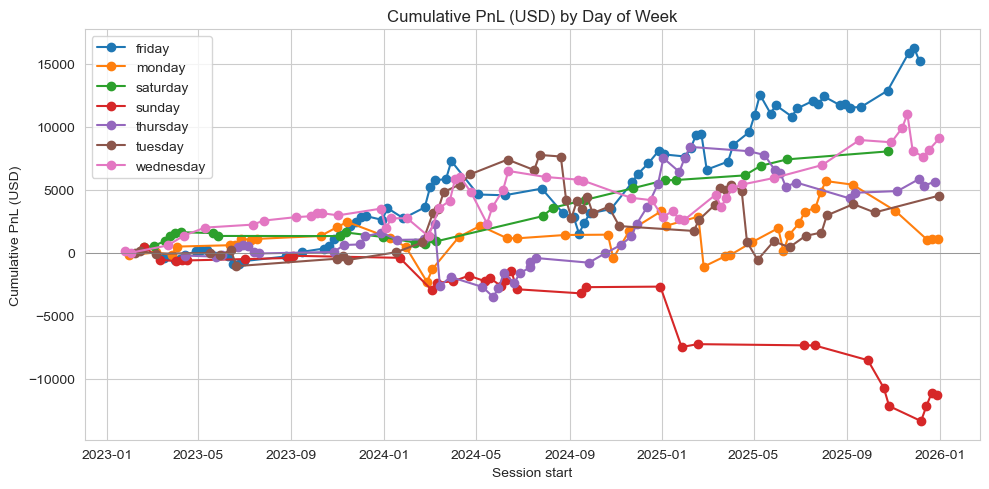

In [ ]:
def make_charts(session_signals, trades_df, pnl_df):
    signals = session_signals.copy()
    signals['session_start'] = pd.to_datetime(session_signals['session_start'], utc=True)

    pnl = pnl_df.copy()
    pnl['session_start'] = pd.to_datetime(pnl['session_start'], utc=True)
    pnl = pnl.merge(signals[['session_start', 'session_type', 'session_dow']], on='session_start', how='left', suffixes=["", "_1"])
    pnl = pnl.sort_values('session_start')
    pnl = pnl.drop(['session_dow_1', 'session_type_1'], axis=1)

    palette = {'weekend': '#d62728', 'weekday': '#1f77b4'}

    fig, ax = plt.subplots(figsize=(10, 5))
    for stype, grp in pnl.groupby('session_dow'):
        grp = grp.sort_values('session_start').copy()
        grp['cum'] = grp['gross_pnl_usd'].cumsum()
        ax.plot(grp['session_start'], grp['cum'], marker='o', label=stype, color=palette.get(stype))
    ax.set_title('Cumulative PnL (USD) by Day of Week')
    ax.set_xlabel('Session start'); ax.set_ylabel('Cumulative PnL (USD)')
    ax.axhline(0, color='grey', lw=0.5); ax.legend(); fig.tight_layout()
    plt.show()

make_charts(session_signals, trades_short, pnl_short)


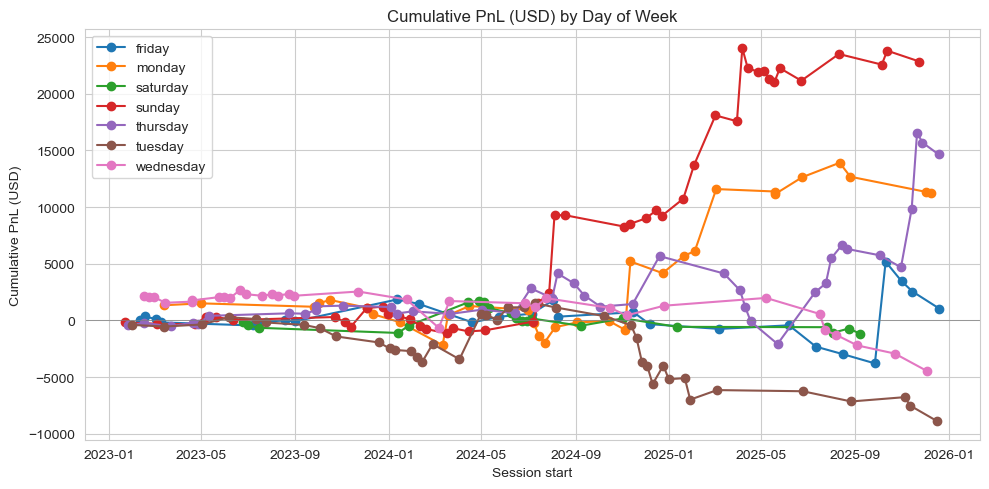

In [89]:
make_charts(session_signals, trades_long, pnl_long)

In [ ]:
def make_charts(session_signals, trades_df, pnl_df):
    ss = session_signals.copy()
    ss['session_start'] = pd.to_datetime(ss['session_start'], utc=True)

    pnl = pnl_df.copy()
    pnl['session_start'] = pd.to_datetime(pnl['session_start'], utc=True)
    pnl = pnl.merge(ss[['session_start', 'session_type']], on='session_start', how='left')
    pnl = pnl.sort_values('session_start')

    palette = {'weekend': '#d62728', 'weekday': '#1f77b4'}

    # 1. Cumulative PnL (USD) by session type
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype, grp in pnl.groupby('session_type'):
        grp = grp.sort_values('session_start').copy()
        grp['cum'] = grp['gross_pnl_usd'].cumsum()
        ax.plot(grp['session_start'], grp['cum'], marker='o', label=stype, color=palette.get(stype))
    ax.set_title('Cumulative PnL (USD) by Session Type')
    ax.set_xlabel('Session start'); ax.set_ylabel('Cumulative PnL (USD)')
    ax.axhline(0, color='grey', lw=0.5); ax.legend(); fig.tight_layout()
    plt.show()

    # 2. VRP distribution histogram, weekend vs weekday overlaid
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype in ['weekend', 'weekday']:
        vals = ss.loc[ss['session_type'] == stype, 'vrp'].dropna()
        ax.hist(vals, bins=40, alpha=0.5, label=f'{stype} (n={len(vals)})', color=palette[stype])
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0.05, color='green', lw=0.8, linestyle=':', label='signal threshold (0.05)')
    ax.set_title('VRP Distribution: Weekend vs Weekday')
    ax.set_xlabel('VRP (atm_iv - rv_benchmark)'); ax.set_ylabel('Count')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 3. IV vs RV scatter, coloured by session type
    fig, ax = plt.subplots(figsize=(8, 8))
    for stype in ['weekend', 'weekday']:
        sub = ss[ss['session_type'] == stype]
        ax.scatter(sub['rv_benchmark'], sub['atm_iv'], alpha=0.6, label=stype,
                   color=palette[stype], s=25)
    lo = min(ss['rv_benchmark'].min(), ss['atm_iv'].min())
    hi = max(ss['rv_benchmark'].max(), ss['atm_iv'].max())
    ax.plot([lo, hi], [lo, hi], color='black', lw=0.8, linestyle='--', label='IV = RV')
    ax.set_title('ATM IV vs Realised Vol by Session Type')
    ax.set_xlabel('RV'); ax.set_ylabel('ATM IV (annualised)')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 4. Signal frequency by month
    sig = ss[ss['signal'].astype(bool)].copy()
    sig['month'] = sig['session_start'].dt.to_period('M').astype(str)
    counts = sig.groupby(['month', 'session_type']).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 5))
    counts.plot(kind='bar', stacked=True, ax=ax,
                color=[palette.get(c, 'grey') for c in counts.columns])
    ax.set_title('Signal Frequency by Month')
    ax.set_xlabel('Month'); ax.set_ylabel('Number of signals')
    ax.legend(title='session_type'); fig.tight_layout()
    plt.show()

In [56]:
def make_charts(session_signals, pnl_short=None, pnl_long=None, combined_pnl=None):
    """
    Make project charts for VRP research and strategy performance.

    Parameters
    ----------
    session_signals : pd.DataFrame
        Must contain at least:
        - session_start
        - session_type
        - atm_iv
        - rv_benchmark
        - vrp
        - session_dow
        Optional:
        - signal_short
        - signal_long
        - vrp_z
    pnl_short : pd.DataFrame or None
        Session-level PnL for short strategy.
        Must contain at least:
        - session_start
        - gross_pnl_usd
        Optional:
        - session_type
    pnl_long : pd.DataFrame or None
        Session-level PnL for long strategy.
        Must contain at least:
        - session_start
        - gross_pnl_usd
        Optional:
        - session_type
    combined_pnl : pd.DataFrame or None
        Optional pre-combined session-level PnL frame. If provided, it should
        contain columns:
        - session_start
        - gross_pnl_usd
        - strategy
        Optional:
        - session_type

    Returns
    -------
    dict
        Dictionary of prepared dataframes used in the charts.
    """
    sns.set_style("whitegrid")

    # ------------------------------------------------------------
    # Prepare session_signals
    # ------------------------------------------------------------
    ss = session_signals.copy()
    ss["session_start"] = pd.to_datetime(ss["session_start"], utc=True, errors="coerce")
    ss = ss.sort_values("session_start").reset_index(drop=True)

    if "session_type" not in ss.columns:
        raise ValueError("session_signals must contain 'session_type'.")
    if "vrp" not in ss.columns:
        raise ValueError("session_signals must contain 'vrp'.")
    if "atm_iv" not in ss.columns:
        raise ValueError("session_signals must contain 'atm_iv'.")
    if "rv_benchmark" not in ss.columns:
        raise ValueError("session_signals must contain 'rv_benchmark'.")

    ss["session_type"] = ss["session_type"].astype(str).str.lower()
    if "session_dow" in ss.columns:
        ss["session_dow"] = ss["session_dow"].astype(str).str.lower()

    palette = {"weekend": "#d62728", "weekday": "#1f77b4"}
    strategy_palette = {"short": "#d62728", "long": "#1f77b4"}

    # ------------------------------------------------------------
    # Prepare combined pnl
    # ------------------------------------------------------------
    pnl_frames = []

    if combined_pnl is not None:
        cp = combined_pnl.copy()
        cp["session_start"] = pd.to_datetime(cp["session_start"], utc=True, errors="coerce")
        cp = cp.sort_values("session_start").reset_index(drop=True)
        if "strategy" not in cp.columns:
            cp["strategy"] = "combined"
        pnl_frames.append(cp)

    if pnl_short is not None:
        ps = pnl_short.copy()
        ps["session_start"] = pd.to_datetime(ps["session_start"], utc=True, errors="coerce")
        ps["strategy"] = "short"
        pnl_frames.append(ps)

    if pnl_long is not None:
        pl = pnl_long.copy()
        pl["session_start"] = pd.to_datetime(pl["session_start"], utc=True, errors="coerce")
        pl["strategy"] = "long"
        pnl_frames.append(pl)

    if not pnl_frames:
        raise ValueError("Provide at least one of pnl_short, pnl_long, or combined_pnl.")

    pnl = pd.concat(pnl_frames, ignore_index=True, sort=False)
    pnl = pnl.sort_values("session_start").reset_index(drop=True)

    if "gross_pnl_usd" not in pnl.columns:
        raise ValueError("PnL frame(s) must contain 'gross_pnl_usd'.")

    if "session_type" not in pnl.columns:
        pnl = pnl.merge(
            ss[["session_start", "session_type"]],
            on="session_start",
            how="left",
            validate="many_to_one",
        )

    pnl["session_type"] = pnl["session_type"].astype(str).str.lower()

    # ------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------
    def _running_drawdown(series: pd.Series) -> pd.DataFrame:
        s = series.fillna(0.0).cumsum()
        peak = s.cummax()
        dd = s - peak
        return pd.DataFrame({"equity": s, "peak": peak, "drawdown": dd})

    def _signal_rate(df: pd.DataFrame, signal_col: str) -> pd.DataFrame:
        if signal_col not in df.columns:
            return pd.DataFrame(columns=["month", "session_type", "signal_rate", "n_sessions", "n_signals"])
        tmp = df.copy()
        tmp["month"] = tmp["session_start"].dt.to_period("M").astype(str)
        tmp[signal_col] = tmp[signal_col].fillna(False).astype(bool)
        out = (
            tmp.groupby(["month", "session_type"])
            .agg(
                n_sessions=("session_start", "size"),
                n_signals=(signal_col, "sum"),
            )
            .reset_index()
        )
        out["signal_rate"] = out["n_signals"] / out["n_sessions"]
        return out

    def _safe_minmax(series_list):
        vals = pd.concat([s.dropna() for s in series_list if s is not None and len(s.dropna()) > 0], axis=0)
        if vals.empty:
            return 0.0, 1.0
        lo = float(vals.min())
        hi = float(vals.max())
        if np.isclose(lo, hi):
            hi = lo + 1e-6
        return lo, hi

    # ============================================================
    # Figure 1: Cumulative PnL and Drawdown
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for strat, grp in pnl.groupby("strategy", dropna=False):
        grp = grp.sort_values("session_start").copy()
        eq = _running_drawdown(grp["gross_pnl_usd"])
        color = strategy_palette.get(str(strat).lower(), None)
        axes[0].plot(
            grp["session_start"],
            eq["equity"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=f"{strat} equity",
            color=color,
        )
        axes[1].plot(
            grp["session_start"],
            eq["drawdown"],
            linewidth=1.5,
            label=f"{strat} drawdown",
            color=color,
        )

    axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.6)
    axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.6)

    axes[0].set_title("Cumulative PnL by Strategy")
    axes[0].set_ylabel("Cumulative PnL (USD)")
    axes[0].legend()

    axes[1].set_title("Running Drawdown by Strategy")
    axes[1].set_xlabel("Session start")
    axes[1].set_ylabel("Drawdown (USD)")
    axes[1].legend()

    fig.tight_layout()
    plt.show()

    # ============================================================
    # Figure 2: VRP distribution by session type
    # ============================================================
    fig, ax = plt.subplots(figsize=(12, 6))

    weekend_vrp = ss.loc[ss["session_type"] == "weekend", "vrp"].dropna()
    weekday_vrp = ss.loc[ss["session_type"] == "weekday", "vrp"].dropna()

    bins = np.histogram_bin_edges(
        pd.concat([weekend_vrp, weekday_vrp], axis=0),
        bins=40
    )

    ax.hist(
        weekday_vrp,
        bins=bins,
        density=True,
        alpha=0.45,
        label=f"weekday (n={len(weekday_vrp)})",
        color=palette["weekday"],
        edgecolor="white",
    )
    ax.hist(
        weekend_vrp,
        bins=bins,
        density=True,
        alpha=0.45,
        label=f"weekend (n={len(weekend_vrp)})",
        color=palette["weekend"],
        edgecolor="white",
    )

    ax.axvline(0, color="black", linewidth=1.0, linestyle="--", label="VRP = 0")
    ax.set_title("VRP Distribution: Weekend vs Weekday")
    ax.set_xlabel("VRP = ATM IV - RV benchmark")
    ax.set_ylabel("Density")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # ============================================================
    # Figure 3: ATM IV vs RV benchmark, faceted by session type
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

    lo, hi = _safe_minmax([ss["rv_benchmark"], ss["atm_iv"]])

    for ax, stype in zip(axes, ["weekday", "weekend"]):
        sub = ss.loc[ss["session_type"] == stype].dropna(subset=["rv_benchmark", "atm_iv"]).copy()

        ax.scatter(
            sub["rv_benchmark"],
            sub["atm_iv"],
            alpha=0.6,
            s=25,
            color=palette[stype],
            edgecolor="none",
        )
        ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.0, label="IV = RV")

        if len(sub) >= 2:
            x = sub["rv_benchmark"].to_numpy()
            y = sub["atm_iv"].to_numpy()
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(lo, hi, 100)
            ax.plot(xs, m * xs + b, color="darkgreen", linewidth=1.2, label="fit")

        ax.set_title(f"ATM IV vs RV benchmark: {stype}")
        ax.set_xlabel("RV benchmark")
        ax.set_ylabel("ATM IV")
        ax.legend()

    fig.tight_layout()
    plt.show()

    # ============================================================
    # Figure 4: Monthly signal rate
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, sigcol, title in [
        (axes[0], "signal_short", "Short Strategy Signal Rate by Month"),
        (axes[1], "signal_long", "Long Strategy Signal Rate by Month"),
    ]:
        if sigcol in ss.columns:
            tmp = _signal_rate(ss, sigcol)
            if not tmp.empty:
                pivot = tmp.pivot(index="month", columns="session_type", values="signal_rate").fillna(0.0)
                pivot = pivot.reindex(sorted(pivot.index), axis=0)
                pivot.plot(kind="bar", ax=ax, color=[palette.get(c, "grey") for c in pivot.columns])
                ax.set_xlabel("Month")
                ax.set_ylabel("Signal rate")
                ax.set_title(title)
                ax.legend(title="session_type")
            else:
                ax.set_title(f"{title} (no data)")
                ax.axis("off")
        else:
            ax.set_title(f"{title} (missing {sigcol})")
            ax.axis("off")

    fig.tight_layout()
    plt.show()

    # ============================================================
    # Figure 5: PnL distribution by strategy
    # ============================================================
    fig, ax = plt.subplots(figsize=(12, 6))

    for strat, grp in pnl.groupby("strategy", dropna=False):
        vals = grp["gross_pnl_usd"].dropna()
        if len(vals) == 0:
            continue
        ax.hist(
            vals,
            bins=40,
            density=True,
            alpha=0.35,
            label=f"{strat} (n={len(vals)})",
            color=strategy_palette.get(str(strat).lower(), None),
            edgecolor="white",
        )

    ax.axvline(0, color="black", linewidth=1.0, linestyle="--")
    ax.set_title("PnL Distribution by Strategy")
    ax.set_xlabel("Gross PnL (USD)")
    ax.set_ylabel("Density")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # ============================================================
    # Figure 6: VRP vs PnL scatter
    # ============================================================
    fig, ax = plt.subplots(figsize=(11, 6))

    merged = pnl.merge(
        ss[["session_start", "vrp", "session_type"]],
        on="session_start",
        how="left",
        validate="many_to_one",
        suffixes=("", "_ss"),
    )

    for stype in ["weekday", "weekend"]:
        sub = merged.loc[merged["session_type"] == stype].dropna(subset=["vrp", "gross_pnl_usd"])
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["vrp"],
            sub["gross_pnl_usd"],
            alpha=0.6,
            s=30,
            label=stype,
            color=palette[stype],
        )

    ax.axvline(0, color="black", linewidth=1.0, linestyle="--")
    ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
    ax.set_title("VRP vs Gross PnL")
    ax.set_xlabel("VRP")
    ax.set_ylabel("Gross PnL (USD)")
    ax.legend()
    fig.tight_layout()
    plt.show()

    return {
        "session_signals": ss,
        "pnl": pnl,
        "merged_pnl_signals": merged,
    }

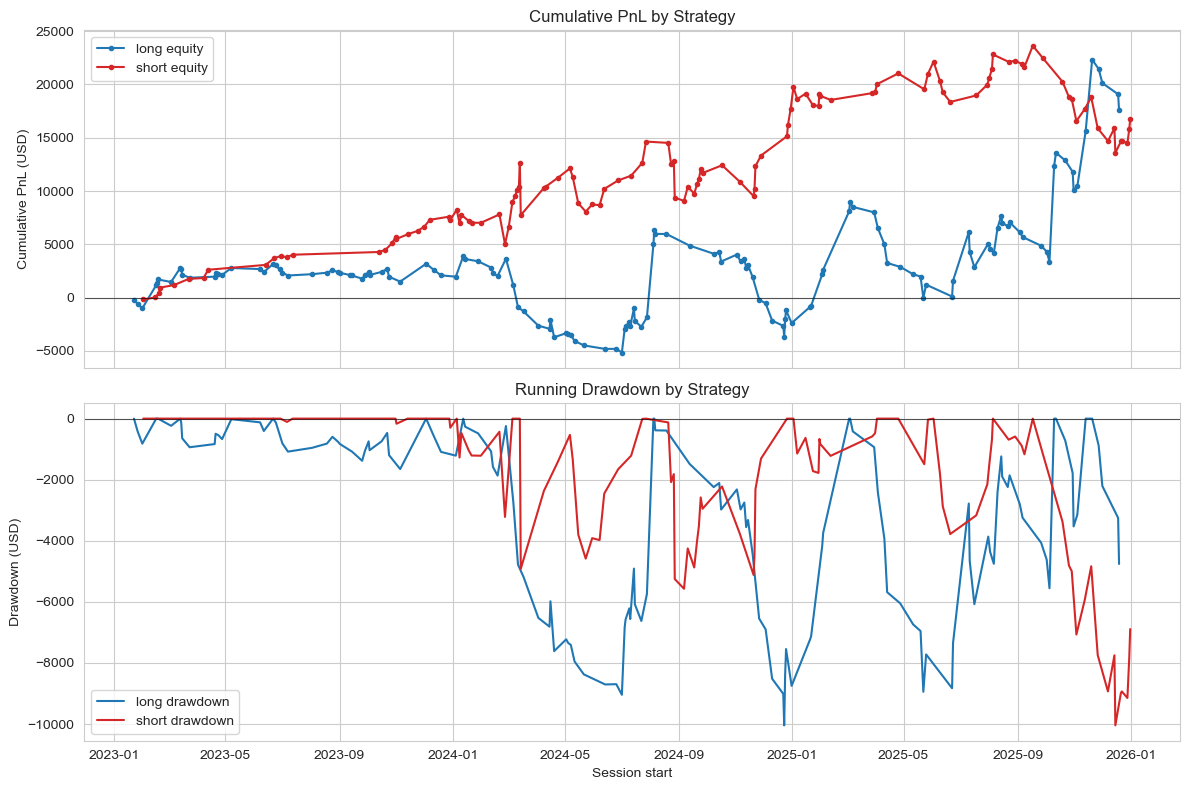

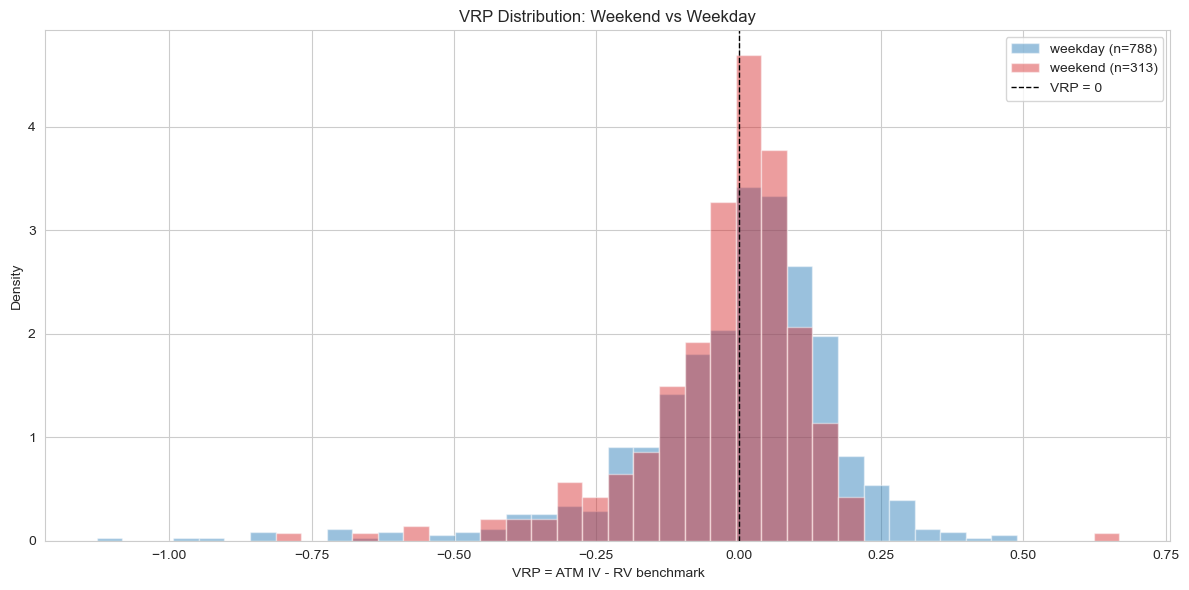

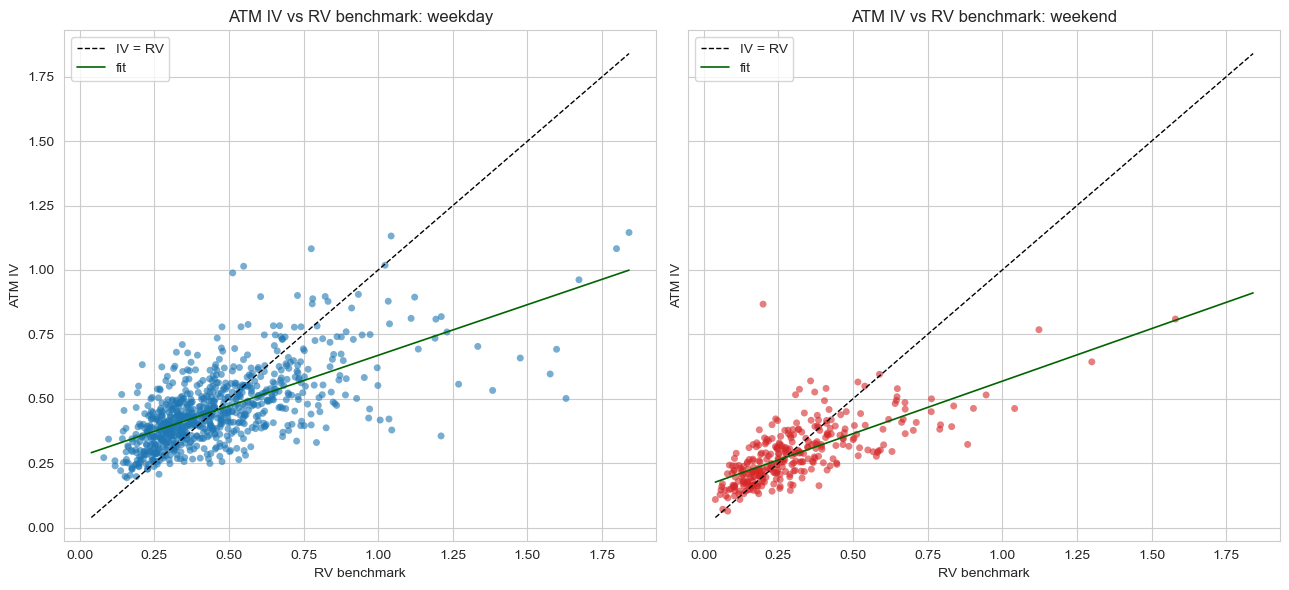

/var/folders/15/jzr9_46j5nl281sqf5zhdsw80000gn/T/ipykernel_9308/2778506467.py:129: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tmp["month"] = tmp["session_start"].dt.to_period("M").astype(str)
/var/folders/15/jzr9_46j5nl281sqf5zhdsw80000gn/T/ipykernel_9308/2778506467.py:129: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tmp["month"] = tmp["session_start"].dt.to_period("M").astype(str)


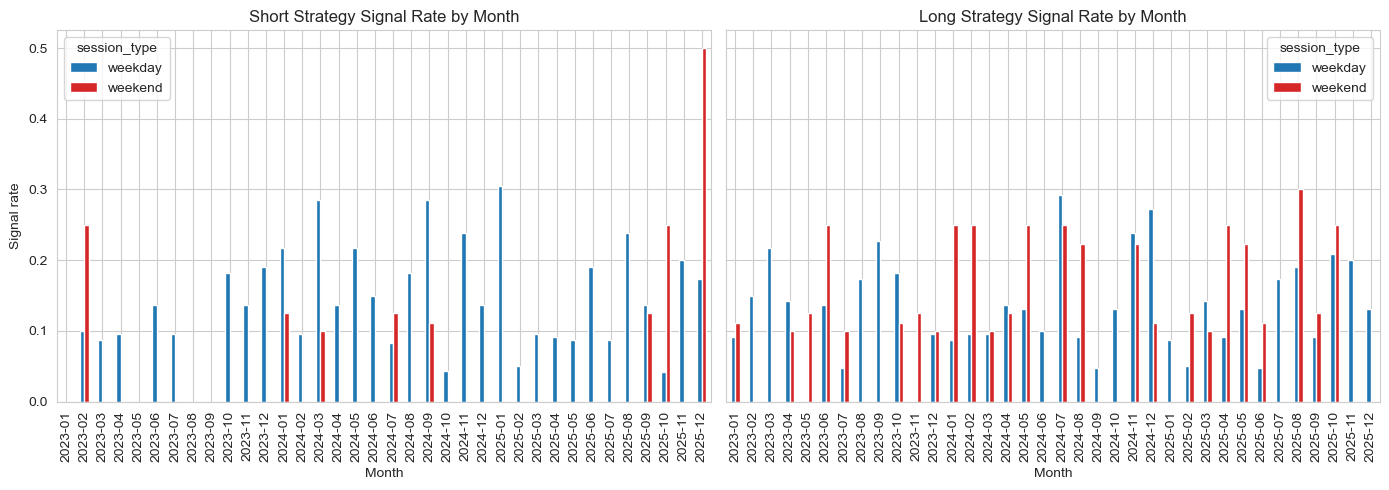

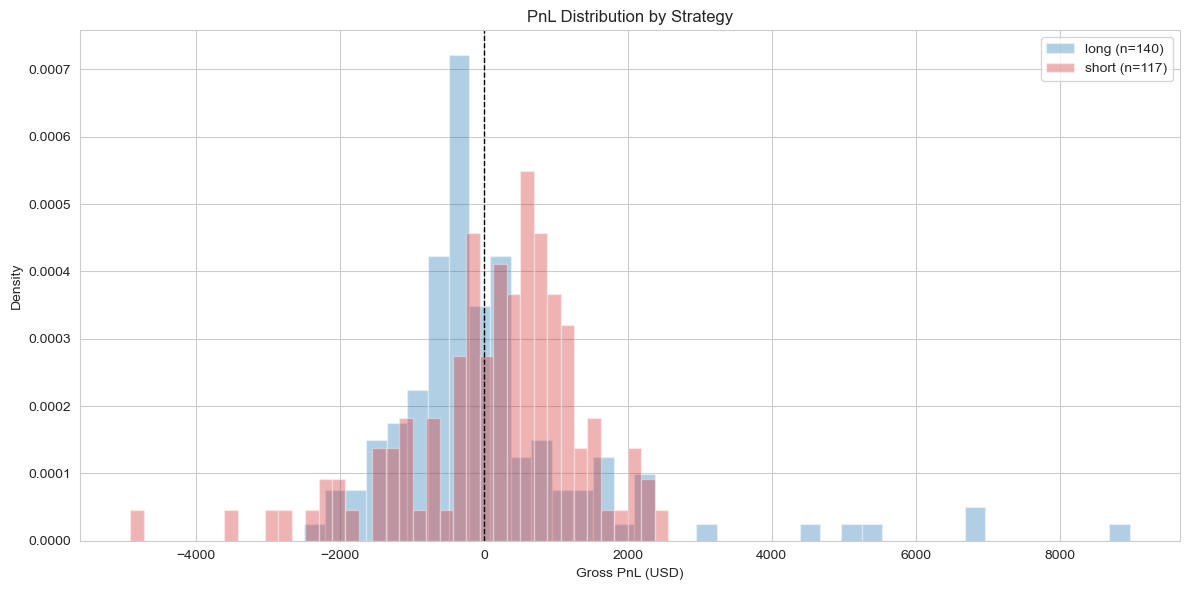

MergeError: Merge keys are not unique in right dataset; not a many-to-one merge

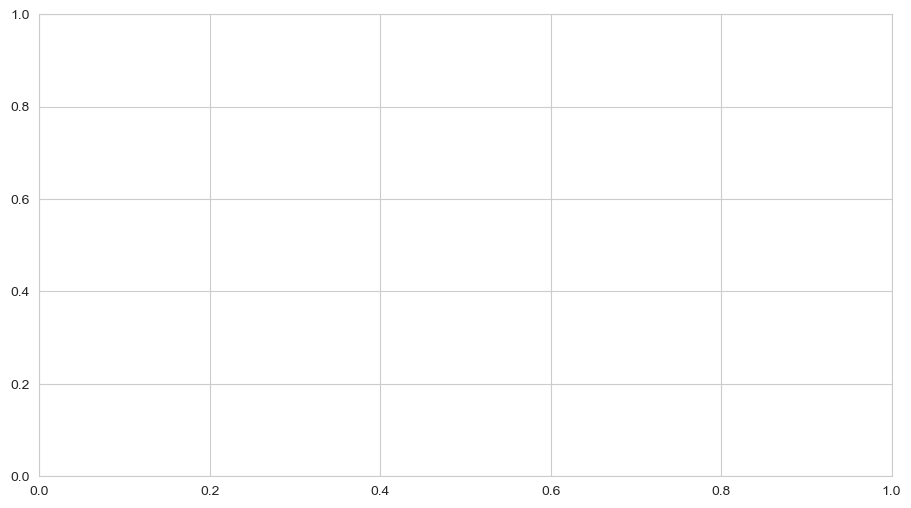

In [57]:
make_charts(session_signals,pnl_short,pnl_long)

In [ ]:
def make_charts(session_signals, trades_df, pnl_df):
    ss = session_signals.copy()
    ss['session_start'] = pd.to_datetime(ss['session_start'], utc=True)

    pnl = pnl_df.copy()
    pnl['session_start'] = pd.to_datetime(pnl['session_start'], utc=True)
    pnl = pnl.merge(ss[['session_start', 'session_type']], on='session_start', how='left')
    pnl = pnl.sort_values('session_start')

    palette = {'weekend': '#d62728', 'weekday': '#1f77b4'}

    # 1. Cumulative PnL (USD) by session type
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype, grp in pnl.groupby('session_type'):
        grp = grp.sort_values('session_start').copy()
        grp['cum'] = grp['gross_pnl_usd'].cumsum()
        ax.plot(grp['session_start'], grp['cum'], marker='o', label=stype, color=palette.get(stype))
    ax.set_title('Cumulative PnL (USD) by Session Type')
    ax.set_xlabel('Session start'); ax.set_ylabel('Cumulative PnL (USD)')
    ax.axhline(0, color='grey', lw=0.5); ax.legend(); fig.tight_layout()
    plt.show()

    # 2. VRP distribution histogram, weekend vs weekday overlaid
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype in ['weekend', 'weekday']:
        vals = ss.loc[ss['session_type'] == stype, 'vrp'].dropna()
        ax.hist(vals, bins=40, alpha=0.5, label=f'{stype} (n={len(vals)})', color=palette[stype])
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0.05, color='green', lw=0.8, linestyle=':', label='signal threshold (0.05)')
    ax.set_title('VRP Distribution: Weekend vs Weekday')
    ax.set_xlabel('VRP (atm_iv - rv_benchmark)'); ax.set_ylabel('Count')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 3. IV vs RV scatter, coloured by session type
    fig, ax = plt.subplots(figsize=(8, 8))
    for stype in ['weekend', 'weekday']:
        sub = ss[ss['session_type'] == stype]
        ax.scatter(sub['rv_benchmark'], sub['atm_iv'], alpha=0.6, label=stype,
                   color=palette[stype], s=25)
    lo = min(ss['rv_benchmark'].min(), ss['atm_iv'].min())
    hi = max(ss['rv_benchmark'].max(), ss['atm_iv'].max())
    ax.plot([lo, hi], [lo, hi], color='black', lw=0.8, linestyle='--', label='IV = RV')
    ax.set_title('ATM IV vs Realised Vol by Session Type')
    ax.set_xlabel('RV'); ax.set_ylabel('ATM IV (annualised)')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 4. Signal frequency by month
    sig = ss[ss['signal'].astype(bool)].copy()
    sig['month'] = sig['session_start'].dt.to_period('M').astype(str)
    counts = sig.groupby(['month', 'session_type']).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 5))
    counts.plot(kind='bar', stacked=True, ax=ax,
                color=[palette.get(c, 'grey') for c in counts.columns])
    ax.set_title('Signal Frequency by Month')
    ax.set_xlabel('Month'); ax.set_ylabel('Number of signals')
    ax.legend(title='session_type'); fig.tight_layout()
    plt.show()

In [ ]:
# CSV outputs
session_signals_short.to_csv('data/session_signals.csv', index=False)
trades_df.to_csv('data/trades_df.csv', index=False)
pnl_df.to_csv('data/pnl_df.csv', index=False)
print("Wrote: data/session_signals.csv, data/trades_df.csv, data/pnl_df.csv")

Wrote: data/session_signals.csv, data/trades_df.csv, data/pnl_df.csv


In [174]:
session_signals = pd.read_csv('data/session_signals.csv')
session_signals.head(10)

,session_start,session_close,session_type,session_dow,atm_iv,iv_52w_low,iv_52w_high,iv_rank,rv_5d,rv_1d,dow_multiplier,rv_benchmark,dow_multiplier_yesterday,vrp,vrp_ratio,signal
0,2025-01-01 08:00:00+00:00,2025-01-02 08:00:00+00:00,weekday,wednesday,0.43040,0.43040,0.43040,50.000000,0.445885,0.443133,1.030909,0.384248,1.188893,0.046152,1.120109,False
1,2025-01-02 08:00:00+00:00,2025-01-03 08:00:00+00:00,weekday,thursday,0.53770,0.43040,0.53770,99.999068,0.428175,0.278075,0.977428,0.263649,1.030909,0.274051,2.039456,True
2,2025-01-03 08:00:00+00:00,2025-01-04 08:00:00+00:00,weekday,friday,0.40305,0.40305,0.53770,0.000743,0.453635,0.369986,0.876929,0.331945,0.977428,0.071105,1.214209,False
3,2025-01-04 08:00:00+00:00,2025-01-05 08:00:00+00:00,weekend,saturday,0.20875,0.20875,0.20875,50.000000,0.450444,0.254323,0.515801,0.149590,0.876929,0.059160,1.395477,False
4,2025-01-05 08:00:00+00:00,2025-01-06 08:00:00+00:00,weekend,sunday,0.28990,0.20875,0.28990,99.998768,0.319245,0.185265,0.816020,0.293098,0.515801,-0.003198,0.989091,False
5,2025-01-06 08:00:00+00:00,2025-01-07 08:00:00+00:00,weekday,monday,0.45750,0.40305,0.53770,40.438315,0.267061,0.208302,1.147363,0.292883,0.816020,0.164617,1.562056,True
6,2025-01-06 08:00:00+00:00,2025-01-07 08:00:00+00:00,weekday,monday,0.45750,0.40305,0.53770,40.438315,0.267050,0.204254,1.151038,0.278831,0.843175,0.178669,1.640777,True
7,2025-01-07 08:00:00+00:00,2025-01-08 08:00:00+00:00,weekday,tuesday,0.42500,0.40305,0.53770,16.302023,0.297373,0.422425,1.252925,0.459817,1.151038,-0.034817,0.924281,False
8,2025-01-08 08:00:00+00:00,2025-01-09 08:00:00+00:00,weekday,wednesday,0.50895,0.40305,0.53770,78.647922,0.356420,0.566925,1.041904,0.471442,1.252925,0.037508,1.079560,False
9,2025-01-09 08:00:00+00:00,2025-01-10 08:00:00+00:00,weekday,thursday,0.48785,0.40305,0.53770,62.977899,0.399674,0.472456,1.001861,0.454298,1.041904,0.033552,1.073854,False


In [108]:
import pandas as pd
import numpy as np

sessions = pd.read_csv("data/sessions.csv")

sessions["session_start"] = pd.to_datetime(sessions["session_start"], utc=True)
sessions["session_close"] = pd.to_datetime(sessions["session_close"], utc=True)

# If session_dow already exists as text like "saturday"
sessions["session_dow"] = sessions["session_dow"].str.lower()

sessions["session_type"] = np.where(
    sessions["session_dow"].isin(["saturday", "sunday"]),
    "weekend",
    "weekday"
)

sessions.to_csv("data/sessions.csv", index=False)